In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading dataset
df_raw = pd.read_excel('Dataset_for_Data_Analytics.xlsx')
df = df_raw.copy()
print(df.shape)
df.head()

(1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [2]:
# Exploring dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [3]:
# Statistical summary
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [4]:
# Checking missing values
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [5]:
# Handling missing values
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

# Re-checking missing values
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [6]:
# Checking unique values in categorical columns
cat_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource', 'CouponCode']

for col in cat_cols:
    print(f'{col}: {df[col].unique()}')
    print()

Product: ['Monitor' 'Phone' 'Tablet' 'Chair' 'Printer' 'Laptop' 'Desk']

PaymentMethod: ['Debit Card' 'Online' 'Credit Card' 'Gift Card' 'Cash']

OrderStatus: ['Shipped' 'Cancelled' 'Returned' 'Delivered' 'Pending']

ReferralSource: ['Instagram' 'Referral' 'Email' 'Facebook' 'Google']

CouponCode: ['SAVE10' 'FREESHIP' 'No Coupon' 'WINTER15']



In [7]:
# Counting orders in each categorical column
for col in cat_cols:
    print(df[col].value_counts())
    print()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64



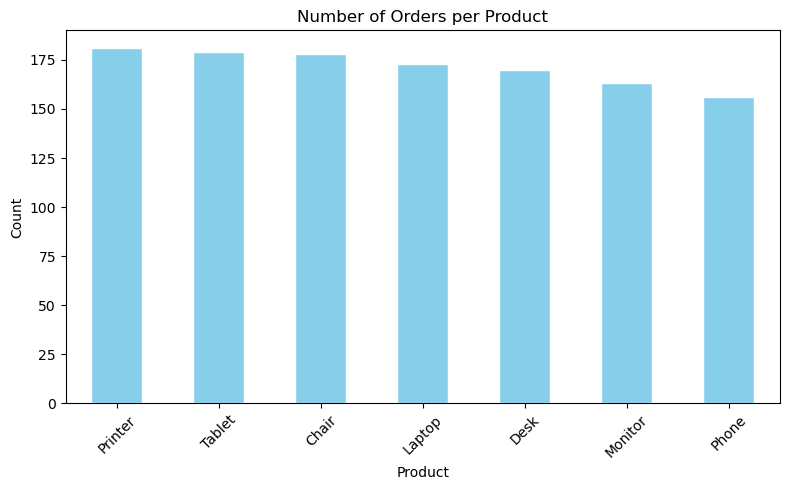

In [8]:
# Bar chart for product order count
plt.figure(figsize=(8, 5))
df['Product'].value_counts().plot(kind='bar', color='skyblue', edgecolor='white')
plt.title('Number of Orders per Product')
plt.xlabel('Product')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("chart1.png", dpi=150, bbox_inches="tight")
plt.show()

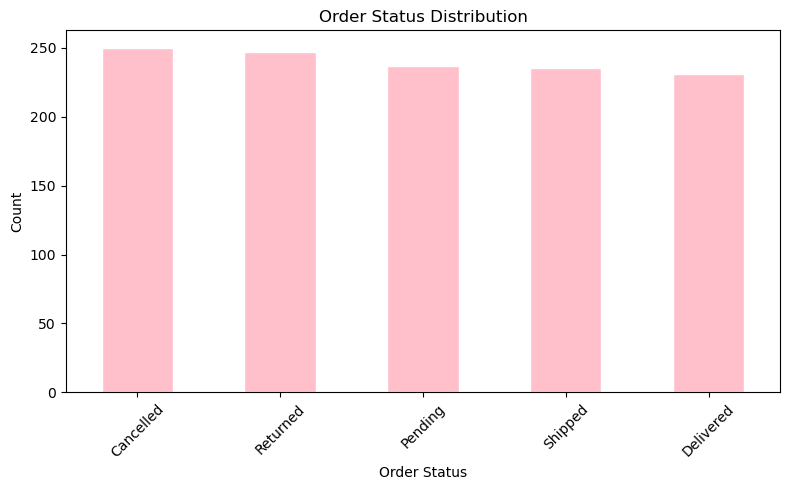

In [9]:
# Bar chart for order status
plt.figure(figsize=(8, 5))
df['OrderStatus'].value_counts().plot(kind='bar', color='pink', edgecolor='white')
plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("chart2.png", dpi=150, bbox_inches="tight")
plt.show()

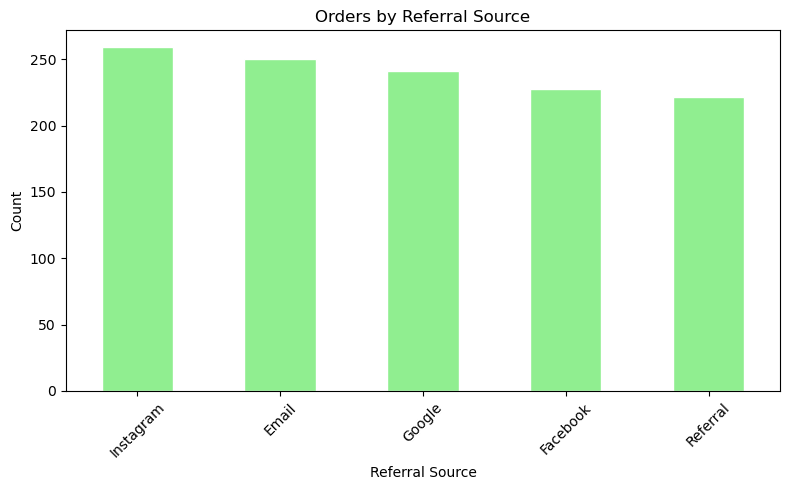

In [10]:
# Bar chart for referral source
plt.figure(figsize=(8, 5))
df['ReferralSource'].value_counts().plot(kind='bar', color='lightgreen', edgecolor='white')
plt.title('Orders by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("chart3.png", dpi=150, bbox_inches="tight")
plt.show()

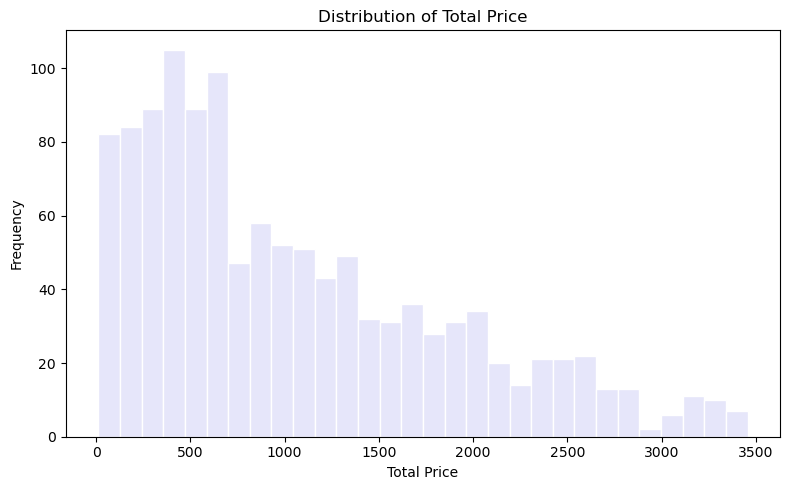

In [11]:
# Histogram to see distribution of TotalPrice
plt.figure(figsize=(8, 5))
df['TotalPrice'].plot(kind='hist', bins=30, color='lavender', edgecolor='white')
plt.title('Distribution of Total Price')
plt.xlabel('Total Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("chart4.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Detecting outliers in TotalPrice using IQR method
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]

print(f'Q1: {Q1}')
print(f'Q3: {Q3}')
print(f'IQR: {IQR}')
print(f'Lower Bound: {lower_bound}')
print(f'Upper Bound: {upper_bound}')
print(f'Number of Outliers: {len(outliers)}')

Q1: 410.52
Q3: 1578.475
IQR: 1167.955
Lower Bound: -1341.4125
Upper Bound: 3330.4075
Number of Outliers: 8


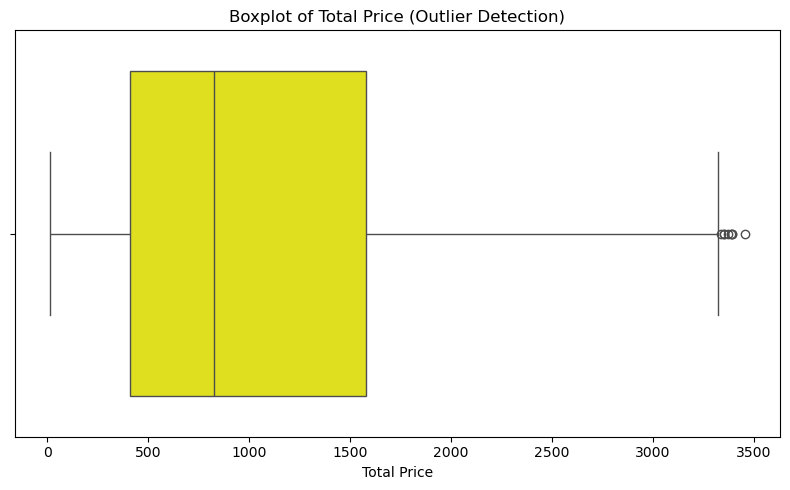

In [13]:
# Boxplot to visualize outliers in TotalPrice
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['TotalPrice'], color='yellow')
plt.title('Boxplot of Total Price (Outlier Detection)')
plt.xlabel('Total Price')
plt.tight_layout()
plt.savefig("chart5.png", dpi=150, bbox_inches="tight")
plt.show()

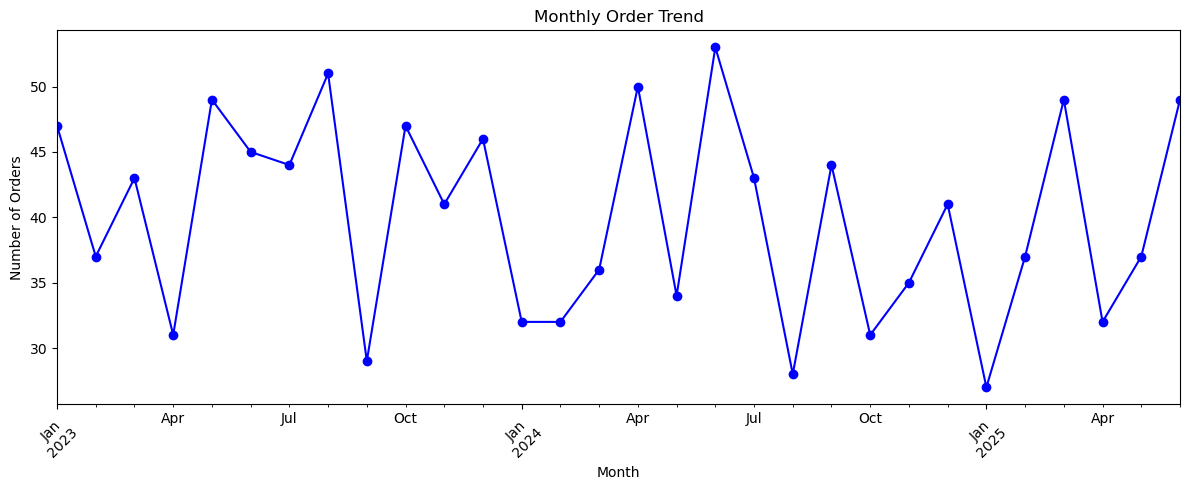

In [14]:
# Extracting month and year from Date column
df['Month'] = df['Date'].dt.to_period('M')

# Counting orders per month
monthly_orders = df.groupby('Month').size()

# Plotting monthly trend
plt.figure(figsize=(12, 5))
monthly_orders.plot(kind='line', color='blue', marker='o')
plt.title('Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("chart6.png", dpi=150, bbox_inches="tight")
plt.show()

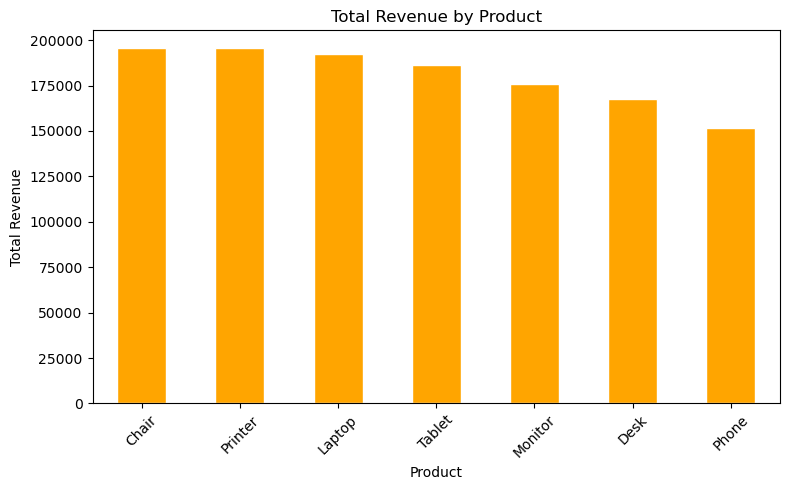

In [15]:
# Total revenue generated by each product
plt.figure(figsize=(8, 5))
df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).plot(kind='bar', color='orange', edgecolor='white')
plt.title('Total Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("chart7.png", dpi=150, bbox_inches="tight")
plt.show()

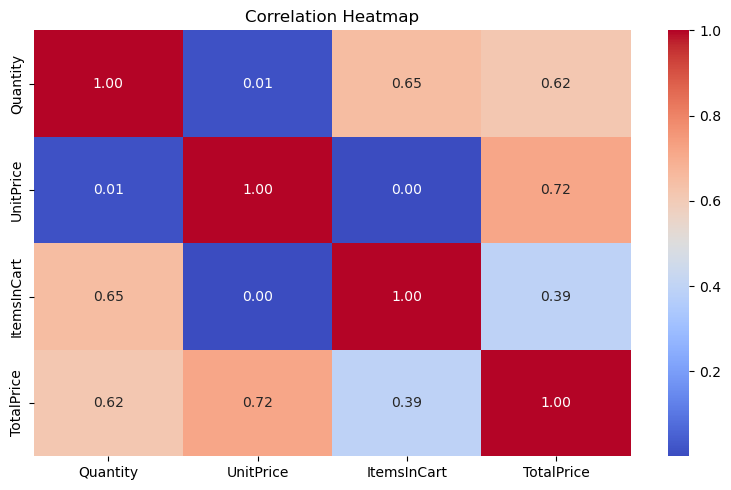

In [16]:
# Correlation between numeric columns
plt.figure(figsize=(8, 5))
sns.heatmap(df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig("chart8.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# Final summary of key findings
print("EDA SUMMARY - KEY OBSERVATIONS")

print(f"\n1. Total Orders: {len(df)}")
print(f"2. Total Revenue: {df['TotalPrice'].sum():,.2f}")
print(f"3. Average Order Value: {df['TotalPrice'].mean():,.2f}")
print(f"4. Median Order Value: {df['TotalPrice'].median():,.2f}")

print(f"\n5. Top Selling Product: {df['Product'].value_counts().idxmax()}")
print(f"6. Top Referral Source: {df['ReferralSource'].value_counts().idxmax()}")
print(f"7. Most Used Payment Method: {df['PaymentMethod'].value_counts().idxmax()}")
print(f"8. Most Common Order Status: {df['OrderStatus'].value_counts().idxmax()}")

print(f"\n9. Missing CouponCode (filled): 309")
print(f"10. Number of Outliers in TotalPrice: {len(outliers)}")

EDA SUMMARY - KEY OBSERVATIONS

1. Total Orders: 1200
2. Total Revenue: 1,264,761.96
3. Average Order Value: 1,053.97
4. Median Order Value: 823.62

5. Top Selling Product: Printer
6. Top Referral Source: Instagram
7. Most Used Payment Method: Online
8. Most Common Order Status: Cancelled

9. Missing CouponCode (filled): 309
10. Number of Outliers in TotalPrice: 8
